# Power Spectrum Model Validation

This notebook validates the power spectrum inference model independently by:
1. Generating synthetic power spectra from theoretical predictions
2. Running MCMC inference to recover cosmological parameters
3. Comparing inferred parameters to true input values

This validates the powerspec_probmodel without requiring full N-body simulations.

## Imports

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
os.environ["EQX_ON_ERROR"] = "nan"
os.environ["JAX_ENABLE_X64"] = "False"

import jax

jax.config.update("jax_enable_x64", False)

from pathlib import Path

import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
from numpyro.handlers import condition, seed, trace
from scipy.stats import norm
from getdist import MCSamples
from getdist import plots as gdplots

from fwd_model_tools import Configurations, Planck18
from fwd_model_tools.powerspec_model import powerspec_probmodel
from fwd_model_tools.sampling import batched_sampling, load_samples

print(f"JAX devices: {jax.device_count()}")
print(f"JAX backend: {jax.default_backend()}")

/home/wassim/micromamba/envs/ffi12/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


JAX devices: 1
JAX backend: gpu


## Configuration Parameters

In [2]:
output_dir = "output_04_powerspec_validation"
nside = 8
max_redshift = 0.5
geometry = "spherical"
num_warmup = 10
num_samples = 5
batch_count = 1
sampler = "MCLMC"
backend = "blackjax"
sigma_e = 0.3
magick_seed = 42

output_dir_path = Path(output_dir)
plots_dir = output_dir_path / "plots"
samples_dir = output_dir_path / "samples_powerspec"
data_dir = output_dir_path / "data"

plots_dir.mkdir(parents=True, exist_ok=True)
samples_dir.mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)

fiducial_cosmology = Planck18()

print(f"Max redshift: {max_redshift}")
print(f"Nside: {nside}")
print(f"Geometry: {geometry}")

Max redshift: 0.5
Nside: 8
Geometry: spherical


## Setup Redshift Distribution

In [3]:
z = jnp.linspace(0, max_redshift, 1000)
z_centers = jnp.linspace(0.2, max_redshift - 0.01, 4)
z_centers = jnp.round(z_centers, 3)
print(f"z_centers = {z_centers}")

nz_shear = [
    jc.redshift.kde_nz(
        z,
        norm.pdf(z, loc=z_center, scale=0.12),
        bw=0.01,
        zmax=max_redshift,
        gals_per_arcmin2=g,
    )
    for z_center, g in zip(z_centers, [7, 8.5, 7.5, 7])
]
nbins = len(nz_shear)
print(f"Number of redshift bins: {nbins}")

z_centers = [0.2   0.297 0.393 0.49 ]
Number of redshift bins: 4


## Create Configuration

In [4]:
lmax = 3 * nside - 1
ell = jnp.arange(2, lmax + 1)

config = Configurations(
    field_size=9.6,
    field_npix=nside,
    box_size=(nside, nside, nside),
    box_size=(1000.0, 1000.0, 1000.0),
    number_of_shells=8,
    density_plane_npix=nside,
    nside=nside,
    density_plane_smoothing=0.1,
    nz_shear=nz_shear,
    fiducial_cosmology=Planck18,
    sigma_e=sigma_e,
    priors={
        "Omega_c": dist.Uniform(0.20, 0.3),
        "sigma8": dist.Uniform(0.6, 1.0),
    },
    t0=0.1,
    dt0=0.1,
    t1=1.0,
    min_redshift=0.01,
    max_redshift=max_redshift,
    sharding=None,
    halo_size=0,
    adjoint=None,
    geometry=geometry,
    observer_position=(0.5, 0.5, 0.5),
    log_lightcone=False,
    log_ic=False,
    ells=ell,
)

print(f"Configuration created with {len(ell)} ell modes")

Configuration created with 22 ell modes


## Generate Synthetic Power Spectra

In [5]:
print("Generating synthetic power spectra observations")

model = powerspec_probmodel(config)

fiducial_model = condition(
    model,
    {
        "Omega_c": fiducial_cosmology.Omega_c,
        "sigma8": fiducial_cosmology.sigma8,
    },
)

print("Tracing fiducial model...")
model_trace = trace(seed(fiducial_model, magick_seed)).get_trace()
print("Model traced successfully")

observed_cls = {
    f"C_ell_auto_{i}": model_trace[f"C_ell_auto_{i}"]["value"]
    for i in range(nbins)
}

np.savez(
    data_dir / "synthetic_cls.npz",
    **observed_cls,
    Omega_c=fiducial_cosmology.Omega_c,
    sigma8=fiducial_cosmology.sigma8,
    ell=ell,
)

print(f"Generated {len(observed_cls)} auto-spectra")
print(f"True Omega_c: {fiducial_cosmology.Omega_c:.4f}")
print(f"True sigma8: {fiducial_cosmology.sigma8:.4f}")

Generating synthetic power spectra observations
Tracing fiducial model...
Model traced successfully
Generated 4 auto-spectra
True Omega_c: 0.2607
True sigma8: 0.8102


## Plot Synthetic Power Spectra

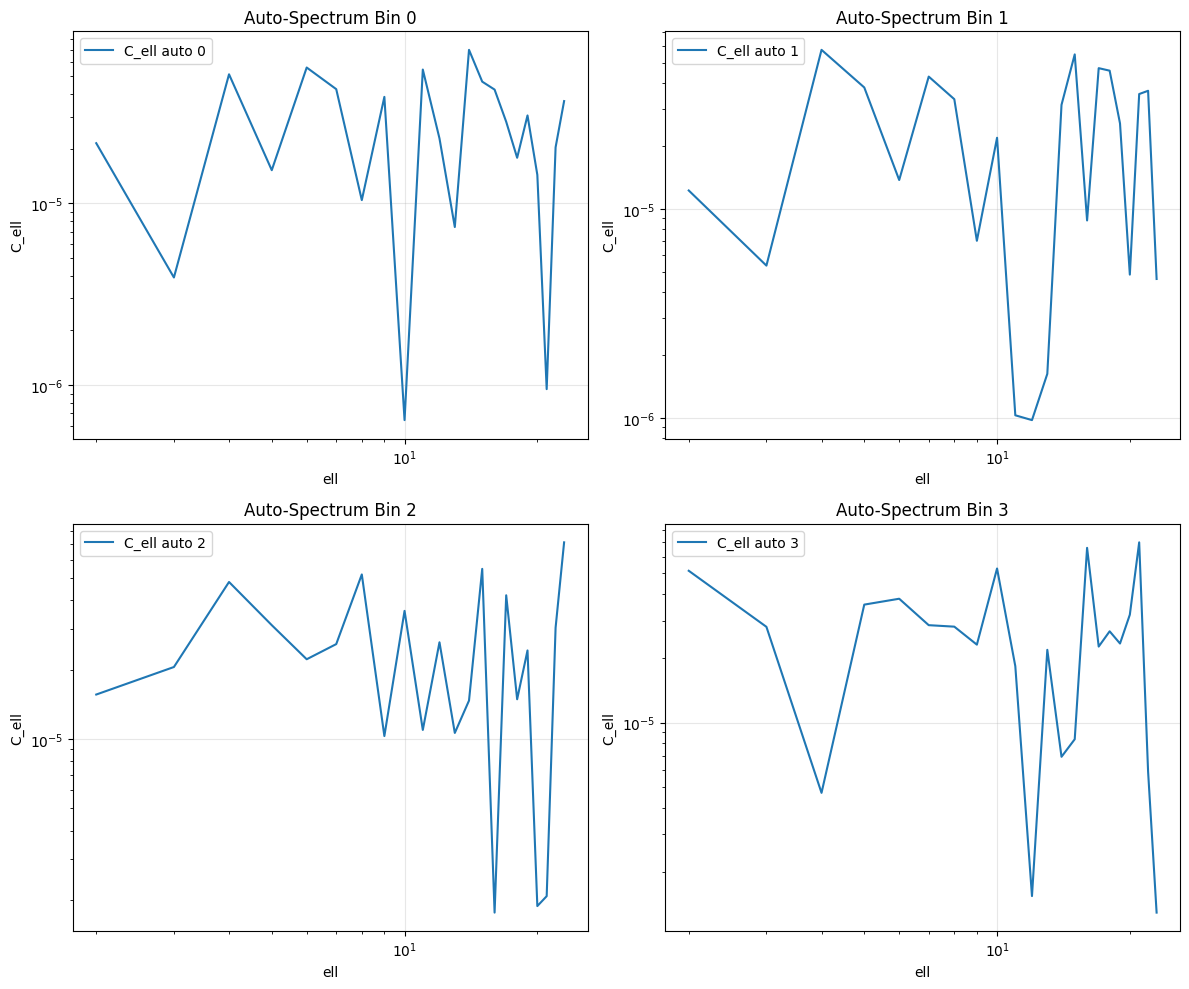

Plotted synthetic power spectra


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i in range(nbins):
    ax = axes[i]
    cl = observed_cls[f"C_ell_auto_{i}"]
    ax.loglog(ell, np.abs(cl), label=f"C_ell auto {i}")
    ax.set_xlabel("ell")
    ax.set_ylabel("C_ell")
    ax.set_title(f"Auto-Spectrum Bin {i}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(plots_dir / "synthetic_power_spectra.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plotted synthetic power spectra")

## Setup Inference Model

In [7]:
print("Setting up power spectrum MCMC inference")

observed_model = condition(model, observed_cls)

init_params = {
    "Omega_c": fiducial_cosmology.Omega_c,
    "sigma8": fiducial_cosmology.sigma8,
}
init_params = jax.tree.map(jnp.asarray, init_params)

print(f"Sampling with {sampler} using {backend} backend")

Setting up power spectrum MCMC inference
Sampling with MCLMC using blackjax backend


## Run MCMC Sampling

In [ ]:
batched_sampling(
    model=observed_model,
    path=str(samples_dir),
    rng_key=jax.random.PRNGKey(magick_seed),
    num_warmup=num_warmup,
    num_samples=num_samples,
    batch_count=batch_count,
    sampler=sampler,
    backend=backend,
    save=True,
    init_params=init_params,
    progress_bar=True,
)

print("MCMC sampling completed")

🔁 Starting fresh with warmup for MCLMC using blackjax...
🔧 Tuning MCLMC parameters (L and step_size)...


## Load and Analyze Samples

In [ ]:
samples = load_samples(str(samples_dir), param_names=["Omega_c", "sigma8"])
print(f"Loaded {len(samples['Omega_c'])} samples")

true_data = np.load(data_dir / "synthetic_cls.npz")
true_Omega_c = float(true_data["Omega_c"])
true_sigma8 = float(true_data["sigma8"])

print("\nPosterior Statistics:")
print(f"Omega_c: {samples['Omega_c'].mean():.4f} ± {samples['Omega_c'].std():.4f}")
print(f"sigma8: {samples['sigma8'].mean():.4f} ± {samples['sigma8'].std():.4f}")

print("\nTrue Values:")
print(f"Omega_c: {true_Omega_c:.4f}")
print(f"sigma8: {true_sigma8:.4f}")

## Plot Posterior Distribution

In [ ]:
params = ("Omega_c", "sigma8")
labels = [r"\Omega_c", r"\sigma_8"]

samples_array = np.column_stack([samples[p] for p in params])
mc_samples = MCSamples(
    samples=samples_array,
    names=params,
    labels=labels,
    label="Power Spectrum Inference"
)

markers_dict = {"Omega_c": true_Omega_c, "sigma8": true_sigma8}

gdplt = gdplots.get_subplot_plotter(width_inch=8)

gdplt.triangle_plot(
    mc_samples,
    filled=True,
    markers=markers_dict,
    title_limit=1,
)

plt.savefig(plots_dir / "posterior.png", dpi=600, bbox_inches="tight")
plt.show()
print("Plotted posterior distribution")